Unforunately, I discovered on March 30th, 2026 that this file was somehow corrupted and all the optimization code and the Smith graph code was lost. I will try to dig through my conversations with Gemini to restore the code. 

In [1]:
# Imports
import numpy as np
from dataclasses import dataclass
from scipy.integrate import solve_ivp
from scipy.signal import hilbert
import matplotlib.pyplot as plt



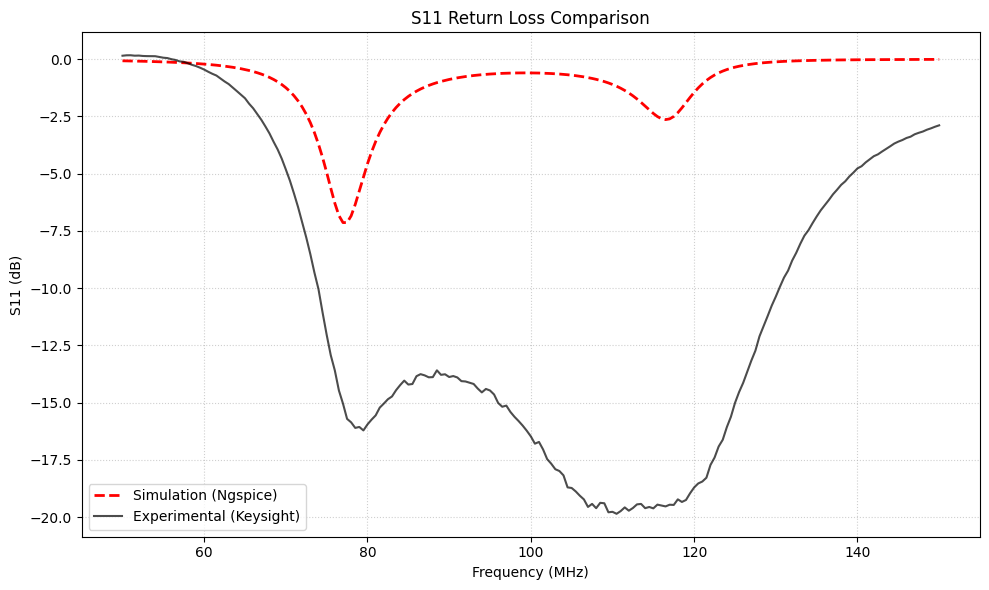

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_s11_comparison(sim_file, exp_file):
    # 1. Load Simulation Data (Ngspice wrdata format)
    # The file is space-separated: [Frequency] [S11_dB]
    df_sim = pd.read_csv(sim_file, sep=r'\s+', header=None, names=['Freq', 'S11_dB'])
    df_sim['Freq_MHz'] = df_sim['Freq'] / 1e6

    # 2. Load Experimental Data (Keysight CSV)
    exp_rows = []
    with open(exp_file, 'r') as f:
        found_begin = False
        for line in f:
            line = line.strip()
            if line == 'BEGIN':
                found_begin = True
                continue
            if line == 'END' or not line:
                break
            if found_begin:
                exp_rows.append(line.split(','))
    
    df_exp = pd.DataFrame(exp_rows, columns=['Freq', 'S11_dB']).astype(float)
    df_exp['Freq_MHz'] = df_exp['Freq'] / 1e6

    # 3. Create the Plot
    plt.figure(figsize=(10, 6))
    
    # Plot Simulation
    plt.plot(df_sim['Freq_MHz'], df_sim['S11_dB'], 
             label='Simulation (Ngspice)', color='red', linestyle='--', linewidth=2)
    
    # Plot Experimental
    plt.plot(df_exp['Freq_MHz'], df_exp['S11_dB'], 
             label='Experimental (Keysight)', color='black', alpha=0.7)

    plt.title('S11 Return Loss Comparison')
    plt.xlabel('Frequency (MHz)')
    plt.ylabel('S11 (dB)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    
    # Show and save
    plt.show()

# Run the script
plot_s11_comparison('sim_power.txt', 'field_fox_data/POWERDB.csv')

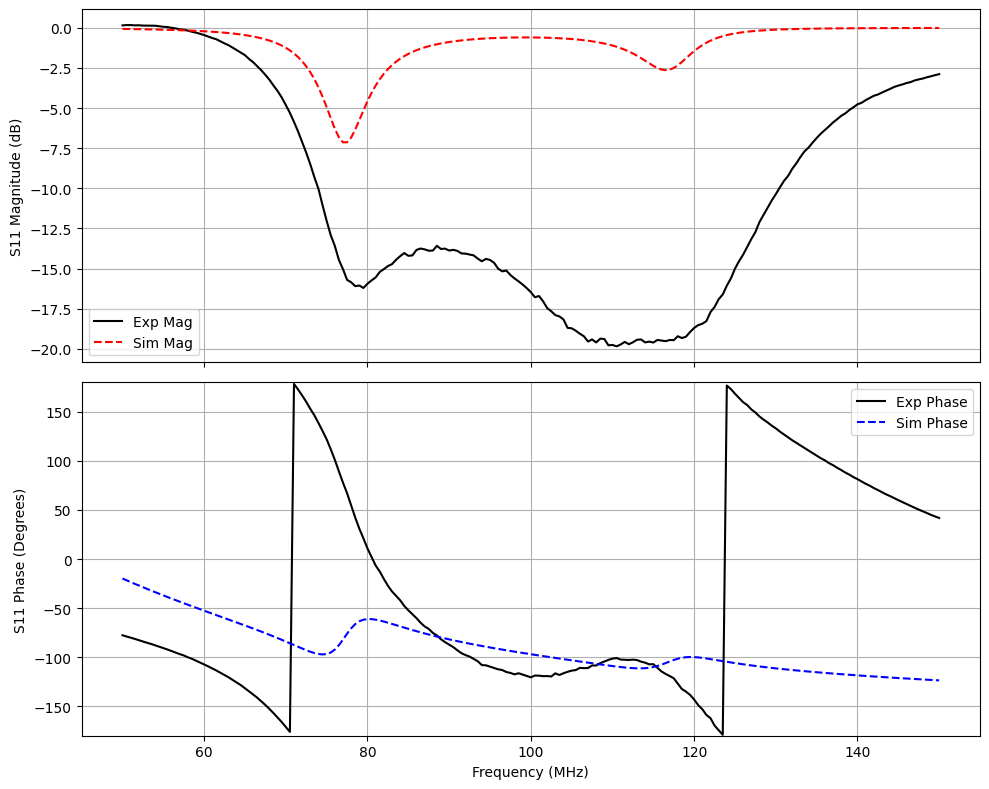

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def load_keysight_csv(filename):
    rows = []
    with open(filename, 'r') as f:
        start = False
        for line in f:
            if 'BEGIN' in line: start = True; continue
            if 'END' in line: break
            if start: rows.append(line.strip().split(','))
    df = pd.DataFrame(rows, columns=['Freq', 'Val']).astype(float)
    df['Freq_MHz'] = df['Freq'] / 1e6
    return df

# Load Experimental Files
df_exp_mag = load_keysight_csv('field_fox_data/POWERDB.csv')
df_exp_ph = load_keysight_csv('field_fox_data/PHASEO.csv')

# Load Simulation Data (wrdata format: Freq, Mag, Freq, Phase)
# Ngspice wrdata repeats the frequency column for every variable
df_sim = pd.read_csv('sim_data.txt', sep=r'\s+', header=None)
sim_freq = df_sim[0] / 1e6
sim_mag = df_sim[1]
sim_ph = df_sim[3]

# Create Figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot Magnitude (Top)
ax1.plot(df_exp_mag['Freq_MHz'], df_exp_mag['Val'], color='black', label='Exp Mag')
ax1.plot(sim_freq, sim_mag, color='red', linestyle='--', label='Sim Mag')
ax1.set_ylabel('S11 Magnitude (dB)')
ax1.legend()
ax1.grid(True)

# Plot Phase (Bottom)
ax2.plot(df_exp_ph['Freq_MHz'], df_exp_ph['Val'], color='black', label='Exp Phase')
ax2.plot(sim_freq, sim_ph, color='blue', linestyle='--', label='Sim Phase')
ax2.set_ylabel('S11 Phase (Degrees)')
ax2.set_xlabel('Frequency (MHz)')
ax2.set_ylim(-180, 180)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()